# Stage Movement and Sample Mapping

Move the stage, acquire overview images, and return to the starting position while mapping the sample.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run scripts/run_servers.py
```


### Imports


In [2]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl


### Ping servers


In [3]:
# DB_HOST = "10.46.217.241"
DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/microscope/default ON
asyncroscopy/data/default ON


### Start Tiled data server


In [4]:
from pathlib import Path
# TILED_HOST = "10.46.217.241"
# TILED_PORT = 9091

TILED_HOST = "localhost"
TILED_PORT = 9091

save_path = Path.cwd().parent / "outputs" / "tiled_acquisitions"
save_path.mkdir(parents=True, exist_ok=True)
print(f"Saving acquired data to: {save_path}")

Saving acquired data to: c:\Users\utkarsh.pratiush\Documents\repos\asyncroscopy\outputs\tiled_acquisitions


In [5]:
data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = str(save_path)

if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

client = from_uri(config.get("uri", f"http://{TILED_HOST}:{TILED_PORT}"))
print("Tiled keys:", list(client))


Tiled server is already running.
{
  "host": "localhost",
  "port": 9091,
  "uri": "http://localhost:9091",
  "save_path": "c:\\Users\\utkarsh.pratiush\\Documents\\repos\\asyncroscopy\\outputs\\tiled_acquisitions",
  "tiled_server": "yes",
  "tiled_server_status": "running; registered path",
  "tiled_server_serving": "c:\\Users\\utkarsh.pratiush\\Documents\\repos\\asyncroscopy\\outputs\\tiled_acquisitions"
}
Tiled keys: ['stem_image_HAADF_20260602T074251210320.h5', 'stem_image_HAADF_20260603T151413278920.h5', 'stem_image_HAADF_BF-S_DF-S_20260603T151625188975.h5', "stem_image_['HAADF']_20260604T123909936109.tiff", 'stem_image_HAADF_20260604T124103341637.h5', "stem_image_['HAADF']_20260604T124340133951.tiff", "stem_image_['HAADF']_20260604T124348937617.tiff", 'stem_image_HAADF_20260604T132409986976.h5', 'stem_image_HAADF_BF-S_DF-S_20260604T132417689146.h5', 'stem_image_20260604T132426343082_HAADF.tiff', 'stem_image_20260604T132426343082_BF-S.tiff', 'stem_image_20260604T132426343082_DF-S.

### Configure the scan


In [9]:
scan.dwell_time   = 1e-6  # µs
scan.imsize  = 512
scan.output_format = ".h5"

print('dwell_time  :', scan.dwell_time)
print('image size :', scan.imsize)


dwell_time  : 1e-06
image size : 512


### Set the field of view


In [10]:
# fov cutoff is 0.52e-9
fov = 0.52e-5
microscope.set_fov(fov)

### Acquire a reference image


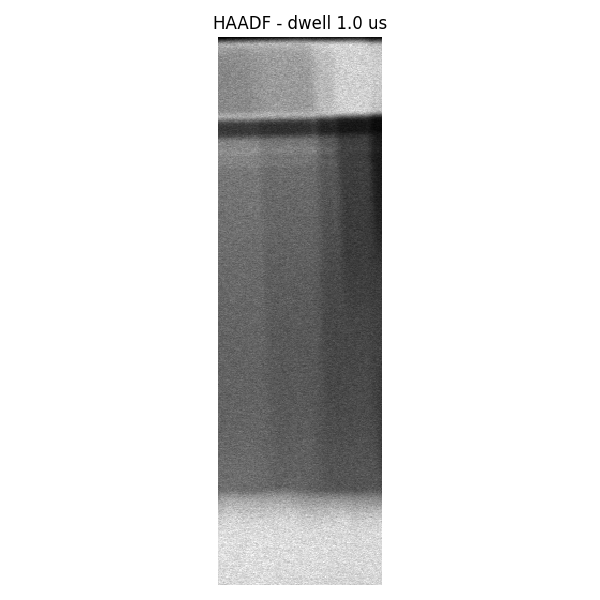

In [11]:
data_key = microscope.acquire_scanned_image(["haadf"])
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Read the current stage position


In [18]:
# get the stage
starting_position = microscope.get_stage()
print('Stage position:', starting_position)


Stage position: [-6.0741299e-05  4.4584725e-04 -1.3128096e-04  1.2800086e-03
  8.3051763e-02]


### Move the stage


In [ ]:
# move the stage
move_by = -10e-6  # 10 µm

# for single tilt holder
# new_position = starting_position + np.array([move_by, 0, 0, 0])

# for double tilt holder
new_position = starting_position + np.array([move_by, 0, 0, 0, 0])

In [24]:
new_position

array([-5.07412985e-05,  4.45847254e-04, -1.31280962e-04,  1.28000858e-03,
        8.30517635e-02])

In [25]:
microscope.move_stage(new_position)

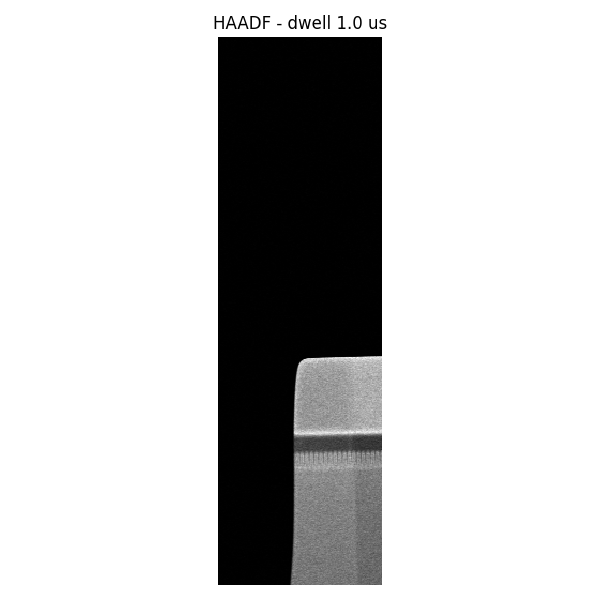

In [26]:
data_key = microscope.acquire_scanned_image(["haadf"])
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()

### Return to the starting position


In [19]:
microscope.move_stage(starting_position)

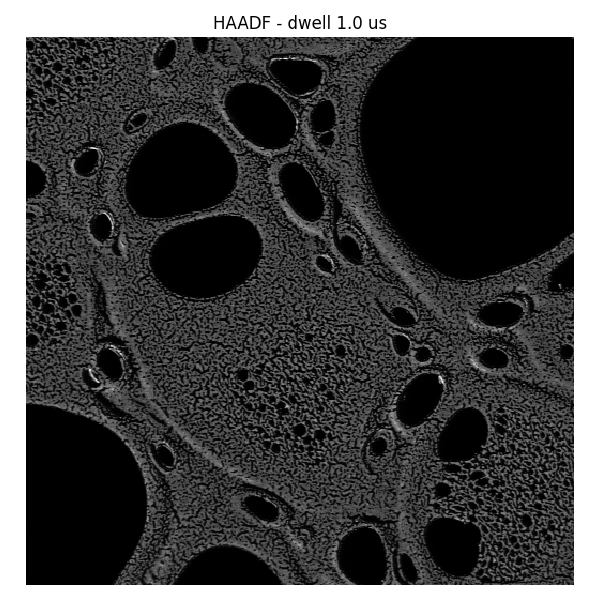

In [20]:
data_key = microscope.acquire_scanned_image(["haadf"])
image = client[data_key]["image"]["HAADF"].read()
metadata = dict(client[data_key]["image"]["HAADF"].metadata)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()